# RQ16 — Channel Ablation

## Research question

> Which acoustic channel representation gives the strongest password-generalising Current-only Digit Scan decisions: target/contact, motor-reference, both channels, or both channels with explicit cross-channel features?

RQ3 established an important source-validity result: true-gate information is present in both recording paths. The reference/motor channel therefore cannot be treated as a pure negative control.

RQ16 asks a different question: **predictive utility under the final controlled dataset protocol**.

### Fixed choices from RQ14 and RQ15

RQ16 changes only channel representation.

Everything else is fixed:

- B01–B07 password-level LOPO;
- Current movement only;
- Absolute feature representation;
- separate `wheel × direction` models;
- A+B training;
- logistic regression `C = 0.10`;
- complete 10-candidate ranking;
- A/B equal-weight score fusion when a matched repeat is available.

The fused 420 repeat-pair decisions are the primary evaluation because that is the repeat policy selected in RQ15. The 840 single-scan decisions are retained as supporting evidence.

### Recovered 695-D feature layout

The frozen MAIN feature extractor produces:

- **Ch1 / target-contact:** 250 features  
  `192 log-Mel + 42 spectral + 16 envelope`
- **Ch2 / motor-reference:** 250 features
- **Ch1 − Ch2 log-Mel:** 192 features
- **cross-channel scalars:** 3  
  correlation, log-RMS ratio, log-peak ratio

Total: **695 features**

### Controlled variants

**Target-only** — first 250 Ch1 features.

**Reference-only** — 250 Ch2 features.

**Dual-no-cross** — Ch1 + Ch2 blocks, 500 features, but no explicit difference/cross terms.

**Dual-full** — all 695 features.

No channel-specific hyperparameter is retuned. This preserves a true one-factor ablation.

## 1. Load the frozen Dataset v1 features

In [1]:
from google.colab import drive
from pathlib import Path
import json

import numpy as np
import pandas as pd
from IPython.display import display

drive.mount("/content/drive")

MYDRIVE = Path("/content/drive/MyDrive")
PROJECT_ROOT = MYDRIVE / "Padlock_Reproduction_v1"

results_candidates = [
    PROJECT_ROOT / "results",
    PROJECT_ROOT
    / "Padlock_Reproduction_v1"
    / "results",
]

RESULTS_ROOT = next(
    (
        p for p in results_candidates
        if (
            p
            / "07_RQ7_Absolute_vs_Relative"
            / "RQ7_candidate_manifest.csv"
        ).exists()
    ),
    None,
)

if RESULTS_ROOT is None:
    raise FileNotFoundError(
        "Could not locate completed RQ7 manifest."
    )

MANIFEST_PATH = (
    RESULTS_ROOT
    / "07_RQ7_Absolute_vs_Relative"
    / "RQ7_candidate_manifest.csv"
)

CACHE_DIR = (
    RESULTS_ROOT
    / "feature_cache"
)

RESULT_DIR = (
    RESULTS_ROOT
    / "16_RQ16_Channel_Ablation"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

BATCHES = [
    "B01_2085",
    "B02_4369",
    "B03_5720",
    "B04_6893",
    "B05_7246",
    "B06_8451",
    "B07_9638",
]

WHEELS = (
    1,
    2,
    4,
)

DIRECTIONS = (
    "CCW",
    "CW",
)

LOGREG_C = 0.10
RANDOM_STATE = 20260820

manifest = pd.read_csv(
    MANIFEST_PATH
)

if "row_id" not in manifest.columns:
    manifest[
        "row_id"
    ] = np.arange(
        len(
            manifest
        ),
        dtype=int,
    )

X = np.empty(
    (
        len(
            manifest
        ),
        695,
    ),
    dtype=np.float64,
)

for batch in BATCHES:
    cache = np.load(
        CACHE_DIR
        / f"{batch}_695d.npz",
        allow_pickle=False,
    )

    run_ids = cache[
        "run_ids"
    ].astype(
        str
    )

    features = cache[
        "features"
    ].astype(
        np.float64
    )

    index = {
        run_id: i
        for i, run_id
        in enumerate(
            run_ids
        )
    }

    batch_manifest = manifest[
        manifest[
            "batch"
        ]
        == batch
    ]

    rows = batch_manifest[
        "row_id"
    ].to_numpy(
        dtype=int
    )

    X[
        rows
    ] = np.vstack([
        features[
            index[
                run_id
            ]
        ]
        for run_id
        in batch_manifest[
            "run_id"
        ]
    ])

assert X.shape == (
    8400,
    695,
)

assert np.isfinite(
    X
).all()

FEATURE_BLOCKS = {
    "Target-only": np.arange(
        0,
        250,
    ),
    "Reference-only": np.arange(
        250,
        500,
    ),
    "Dual-no-cross": np.arange(
        0,
        500,
    ),
    "Dual-full": np.arange(
        0,
        695,
    ),
}

feature_blocks = pd.DataFrame([
    {
        "variant": "Target-only",
        "feature_count": 250,
        "content": (
            "Ch1/contact: 192 log-Mel + "
            "42 spectral + 16 envelope"
        ),
    },
    {
        "variant": "Reference-only",
        "feature_count": 250,
        "content": (
            "Ch2/motor-reference: 192 log-Mel + "
            "42 spectral + 16 envelope"
        ),
    },
    {
        "variant": "Dual-no-cross",
        "feature_count": 500,
        "content": (
            "Ch1 250 + Ch2 250"
        ),
    },
    {
        "variant": "Dual-full",
        "feature_count": 695,
        "content": (
            "Ch1 + Ch2 + 192 difference log-Mel "
            "+ 3 cross scalars"
        ),
    },
])

display(
    feature_blocks
)

Mounted at /content/drive


,variant,feature_count,content
0,Target-only,250,Ch1/contact: 192 log-Mel + 42 spectral + 16 en...
1,Reference-only,250,Ch2/motor-reference: 192 log-Mel + 42 spectral...
2,Dual-no-cross,500,Ch1 250 + Ch2 250
3,Dual-full,695,Ch1 + Ch2 + 192 difference log-Mel + 3 cross s...


## 2. Common model and ranking helpers

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score


def fit_domain_model(
    train_idx,
    test_idx,
    feature_idx,
):
    scaler = StandardScaler()

    X_train = scaler.fit_transform(
        X[
            train_idx
        ][
            :,
            feature_idx,
        ]
    )

    X_test = scaler.transform(
        X[
            test_idx
        ][
            :,
            feature_idx,
        ]
    )

    y_train = manifest.loc[
        train_idx,
        "y",
    ].to_numpy(
        dtype=int
    )

    model = LogisticRegression(
        C=LOGREG_C,
        solver="liblinear",
        class_weight="balanced",
        max_iter=3000,
        random_state=RANDOM_STATE,
    )

    model.fit(
        X_train,
        y_train,
    )

    return model.decision_function(
        X_test
    )


def rank_decisions(
    part,
    variant,
):
    rows = []

    for (
        decision_uid,
        group,
    ) in part.groupby(
        "decision_uid",
        sort=False,
    ):
        ranked = (
            group
            .sort_values(
                "score",
                ascending=False,
            )
            .reset_index(
                drop=True
            )
        )

        true_digit = int(
            ranked[
                "true_digit"
            ].iloc[
                0
            ]
        )

        ranked_digits = (
            ranked[
                "to_digit"
            ]
            .astype(
                int
            )
            .tolist()
        )

        pred_digit = int(
            ranked_digits[
                0
            ]
        )

        true_rank = int(
            ranked_digits.index(
                true_digit
            )
            + 1
        )

        rows.append({
            "variant": variant,
            "heldout_batch": ranked[
                "batch"
            ].iloc[
                0
            ],
            "password": str(
                ranked[
                    "password"
                ].iloc[
                    0
                ]
            ),
            "decision_uid": (
                decision_uid
            ),
            "profile_id": ranked[
                "profile_id"
            ].iloc[
                0
            ],
            "wheel": int(
                ranked[
                    "wheel"
                ].iloc[
                    0
                ]
            ),
            "direction": ranked[
                "direction"
            ].iloc[
                0
            ],
            "repeat_id": ranked[
                "repeat_id"
            ].iloc[
                0
            ],
            "true_digit": (
                true_digit
            ),
            "pred_digit": (
                pred_digit
            ),
            "true_rank": (
                true_rank
            ),
            "top1": int(
                true_rank
                <= 1
            ),
            "top2": int(
                true_rank
                <= 2
            ),
            "top3": int(
                true_rank
                <= 3
            ),
            "reciprocal_rank": (
                1.0
                / true_rank
            ),
        })

    return pd.DataFrame(
        rows
    )


def metric_row(
    frame
):
    return {
        "n_decisions": len(
            frame
        ),
        "top1": frame[
            "top1"
        ].mean(),
        "top2": frame[
            "top2"
        ].mean(),
        "top3": frame[
            "top3"
        ].mean(),
        "mean_true_rank": frame[
            "true_rank"
        ].mean(),
        "median_true_rank": frame[
            "true_rank"
        ].median(),
        "mrr": frame[
            "reciprocal_rank"
        ].mean(),
        "macro_f1": f1_score(
            frame[
                "true_digit"
            ],
            frame[
                "pred_digit"
            ],
            labels=list(
                range(
                    10
                )
            ),
            average="macro",
            zero_division=0,
        ),
    }

## 3. Train each feature block under identical LOPO folds

In [3]:
candidate_parts = []
decision_parts = []

for (
    variant,
    feature_idx,
) in FEATURE_BLOCKS.items():
    for heldout in BATCHES:
        for wheel in WHEELS:
            for direction in DIRECTIONS:
                domain = (
                    manifest[
                        "wheel"
                    ].eq(
                        wheel
                    )
                    &
                    manifest[
                        "direction"
                    ].eq(
                        direction
                    )
                )

                train_mask = (
                    domain
                    &
                    manifest[
                        "batch"
                    ].ne(
                        heldout
                    )
                )

                test_mask = (
                    domain
                    &
                    manifest[
                        "batch"
                    ].eq(
                        heldout
                    )
                )

                train_idx = manifest.index[
                    train_mask
                ].to_numpy()

                test_idx = manifest.index[
                    test_mask
                ].to_numpy()

                scores = fit_domain_model(
                    train_idx,
                    test_idx,
                    feature_idx,
                )

                part = manifest.loc[
                    test_idx
                ].copy()

                part[
                    "variant"
                ] = variant

                part[
                    "score"
                ] = scores

                candidate_parts.append(
                    part
                )

                decision_parts.append(
                    rank_decisions(
                        part,
                        variant,
                    )
                )


candidate_scores = pd.concat(
    candidate_parts,
    ignore_index=True,
)

single_decisions = pd.concat(
    decision_parts,
    ignore_index=True,
)

assert len(
    single_decisions
) == 4 * 840

display(
    single_decisions.head()
)

,variant,heldout_batch,password,decision_uid,profile_id,wheel,direction,repeat_id,true_digit,pred_digit,true_rank,top1,top2,top3,reciprocal_rank
0,Target-only,B01_2085,2085,B01_2085/B01_W1_P01_DSV1_MP2085_CCW_A,B01_W1_P01,1,CCW,A,2,2,1,1,1,1,1.000000
1,Target-only,B01_2085,2085,B01_2085/B01_W1_P01_DSV1_MP2085_CCW_B,B01_W1_P01,1,CCW,B,2,2,1,1,1,1,1.000000
2,Target-only,B01_2085,2085,B01_2085/B01_W1_P02_DSV1_MP2085_CCW_A,B01_W1_P02,1,CCW,A,2,3,6,0,0,0,0.166667
3,Target-only,B01_2085,2085,B01_2085/B01_W1_P02_DSV1_MP2085_CCW_B,B01_W1_P02,1,CCW,B,2,8,4,0,0,0,0.250000
4,Target-only,B01_2085,2085,B01_2085/B01_W1_P03_DSV1_MP2085_CCW_A,B01_W1_P03,1,CCW,A,2,2,1,1,1,1,1.000000


## 4. Apply the fixed RQ15 A/B fusion

In [4]:
fused_decision_parts = []
fused_candidate_parts = []

for variant in FEATURE_BLOCKS:
    scores = candidate_scores[
        candidate_scores[
            "variant"
        ]
        == variant
    ].copy()

    scores[
        "score_z"
    ] = np.nan

    for (
        decision_uid,
        idx,
    ) in scores.groupby(
        "decision_uid"
    ).groups.items():
        idx = np.array(
            list(
                idx
            ),
            dtype=int,
        )

        values = scores.loc[
            idx,
            "score",
        ].to_numpy(
            dtype=float
        )

        std = float(
            np.std(
                values
            )
        )

        scale = (
            std
            if std > 1e-12
            else 1.0
        )

        scores.loc[
            idx,
            "score_z",
        ] = (
            values
            - np.mean(
                values
            )
        ) / scale


    pair_keys = [
        "batch",
        "password",
        "profile_id",
        "wheel",
        "direction",
        "to_digit",
        "true_digit",
    ]

    fused_candidates = (
        scores.groupby(
            pair_keys,
            as_index=False,
        )
        .agg(
            fused_score=(
                "score_z",
                "mean",
            ),
            n_repeats=(
                "repeat_id",
                "nunique",
            ),
            y=(
                "y",
                "first",
            ),
        )
    )

    fused_candidates[
        "variant"
    ] = variant

    fused_candidate_parts.append(
        fused_candidates
    )

    rows = []

    for (
        batch,
        password,
        profile_id,
        wheel,
        direction,
    ), group in fused_candidates.groupby(
        [
            "batch",
            "password",
            "profile_id",
            "wheel",
            "direction",
        ],
        sort=False,
    ):
        ranked = (
            group
            .sort_values(
                "fused_score",
                ascending=False,
            )
            .reset_index(
                drop=True
            )
        )

        true_digit = int(
            ranked[
                "true_digit"
            ].iloc[
                0
            ]
        )

        ranked_digits = (
            ranked[
                "to_digit"
            ]
            .astype(
                int
            )
            .tolist()
        )

        pred_digit = int(
            ranked_digits[
                0
            ]
        )

        true_rank = int(
            ranked_digits.index(
                true_digit
            )
            + 1
        )

        rows.append({
            "variant": (
                variant
            ),
            "heldout_batch": (
                batch
            ),
            "password": str(
                password
            ),
            "profile_id": (
                profile_id
            ),
            "wheel": int(
                wheel
            ),
            "direction": (
                direction
            ),
            "true_digit": (
                true_digit
            ),
            "pred_digit": (
                pred_digit
            ),
            "true_rank": (
                true_rank
            ),
            "top1": int(
                true_rank
                <= 1
            ),
            "top2": int(
                true_rank
                <= 2
            ),
            "top3": int(
                true_rank
                <= 3
            ),
            "reciprocal_rank": (
                1.0
                / true_rank
            ),
        })

    fused_decision_parts.append(
        pd.DataFrame(
            rows
        )
    )


fused_candidates_all = pd.concat(
    fused_candidate_parts,
    ignore_index=True,
)

fused_decisions = pd.concat(
    fused_decision_parts,
    ignore_index=True,
)

assert len(
    fused_decisions
) == 4 * 420

display(
    fused_decisions.head()
)

,variant,heldout_batch,password,profile_id,wheel,direction,true_digit,pred_digit,true_rank,top1,top2,top3,reciprocal_rank
0,Target-only,B01_2085,2085,B01_W1_P01,1,CCW,2,2,1,1,1,1,1.000000
1,Target-only,B01_2085,2085,B01_W1_P01,1,CW,2,2,1,1,1,1,1.000000
2,Target-only,B01_2085,2085,B01_W1_P02,1,CCW,2,3,3,0,0,1,0.333333
3,Target-only,B01_2085,2085,B01_W1_P02,1,CW,2,1,3,0,0,1,0.333333
4,Target-only,B01_2085,2085,B01_W1_P03,1,CCW,2,2,1,1,1,1,1.000000


## 5. Summary and password-level paired tests

In [5]:
from scipy.stats import wilcoxon

summary_rows = []

for (
    evaluation_name,
    frame,
) in [
    (
        "Single-scan",
        single_decisions,
    ),
    (
        "A/B fused",
        fused_decisions,
    ),
]:
    for (
        variant,
        group,
    ) in frame.groupby(
        "variant",
        sort=False,
    ):
        summary_rows.append({
            "evaluation": (
                evaluation_name
            ),
            "scope": "Overall",
            "variant": (
                variant
            ),
            **metric_row(
                group
            ),
        })

        for wheel in WHEELS:
            summary_rows.append({
                "evaluation": (
                    evaluation_name
                ),
                "scope": (
                    f"W{wheel}"
                ),
                "variant": (
                    variant
                ),
                **metric_row(
                    group[
                        group[
                            "wheel"
                        ]
                        == wheel
                    ]
                ),
            })


summary = pd.DataFrame(
    summary_rows
)


password_rows = []

for (
    evaluation_name,
    frame,
) in [
    (
        "Single-scan",
        single_decisions,
    ),
    (
        "A/B fused",
        fused_decisions,
    ),
]:
    for (
        variant,
        heldout_batch,
        password,
    ), group in frame.groupby(
        [
            "variant",
            "heldout_batch",
            "password",
        ],
        sort=False,
    ):
        password_rows.append({
            "evaluation": (
                evaluation_name
            ),
            "variant": (
                variant
            ),
            "heldout_batch": (
                heldout_batch
            ),
            "password": str(
                password
            ),
            **metric_row(
                group
            ),
        })


password_summary = pd.DataFrame(
    password_rows
)


fused_password = (
    password_summary[
        password_summary[
            "evaluation"
        ]
        == "A/B fused"
    ]
    .pivot(
        index=[
            "heldout_batch",
            "password",
        ],
        columns="variant",
        values="top1",
    )
    .reset_index()
)


comparisons = [
    (
        "Reference-only",
        "Target-only",
        "Reference-only vs Target-only",
    ),
    (
        "Dual-no-cross",
        "Target-only",
        "Dual-no-cross vs Target-only",
    ),
    (
        "Dual-full",
        "Target-only",
        "Dual-full vs Target-only",
    ),
    (
        "Dual-full",
        "Dual-no-cross",
        "Dual-full vs Dual-no-cross",
    ),
]

test_rows = []

for (
    A,
    B,
    label,
) in comparisons:
    delta = (
        fused_password[
            A
        ]
        - fused_password[
            B
        ]
    )

    test = wilcoxon(
        fused_password[
            A
        ],
        fused_password[
            B
        ],
        alternative="two-sided",
        method="auto",
    )

    test_rows.append({
        "comparison": (
            label
        ),
        "n_passwords": (
            len(
                fused_password
            )
        ),
        "mean_delta_pp": float(
            100
            * delta.mean()
        ),
        "median_delta_pp": float(
            100
            * delta.median()
        ),
        "A_better_passwords": int(
            (
                delta
                > 0
            ).sum()
        ),
        "equal_passwords": int(
            (
                delta
                == 0
            ).sum()
        ),
        "B_better_passwords": int(
            (
                delta
                < 0
            ).sum()
        ),
        "p_two_sided": float(
            test.pvalue
        ),
    })


tests = pd.DataFrame(
    test_rows
)

display(
    summary[
        summary[
            "scope"
        ]
        == "Overall"
    ].round(
        4
    )
)

display(
    tests.round(
        4
    )
)

,evaluation,scope,variant,n_decisions,top1,top2,top3,mean_true_rank,median_true_rank,mrr,macro_f1
0,Single-scan,Overall,Target-only,840,0.7929,0.9119,0.9560,1.3905,1.0,0.8762,0.7910
4,Single-scan,Overall,Reference-only,840,0.2869,0.4464,0.5714,3.7036,3.0,0.4824,0.2791
8,Single-scan,Overall,Dual-no-cross,840,0.7631,0.9024,0.9488,1.4405,1.0,0.8589,0.7631
12,Single-scan,Overall,Dual-full,840,0.7857,0.9036,0.9548,1.4048,1.0,0.8712,0.7809
16,A/B fused,Overall,Target-only,420,0.8548,0.9452,0.9833,1.2429,1.0,0.9158,0.8605
20,A/B fused,Overall,Reference-only,420,0.3262,0.4976,0.6190,3.4262,3.0,0.5189,0.3177
24,A/B fused,Overall,Dual-no-cross,420,0.8429,0.9476,0.9786,1.2548,1.0,0.9099,0.8430
28,A/B fused,Overall,Dual-full,420,0.8595,0.9548,0.9786,1.2286,1.0,0.9195,0.8601


,comparison,n_passwords,mean_delta_pp,median_delta_pp,A_better_passwords,equal_passwords,B_better_passwords,p_two_sided
0,Reference-only vs Target-only,7,-52.8571,-53.3333,0,0,7,0.0156
1,Dual-no-cross vs Target-only,7,-1.1905,-1.6667,1,2,4,0.4375
2,Dual-full vs Target-only,7,0.4762,1.6667,4,1,2,0.7500
3,Dual-full vs Dual-no-cross,7,1.6667,1.6667,5,2,0,0.0625


## 6. Main figures

In [6]:
import matplotlib.pyplot as plt

DARK_BLUE = "#315B7D"
MID_BLUE = "#6F8FA8"
LIGHT_BLUE = "#AFC5D5"
PALE_BLUE = "#DCE8F0"
MID_GREY = "#9EA5AA"
DARK_GREY = "#596168"

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.labelsize": 10,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})


def save_figure(
    fig,
    stem,
):
    fig.savefig(
        RESULT_DIR
        / f"{stem}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        RESULT_DIR
        / f"{stem}.pdf",
        bbox_inches="tight",
    )

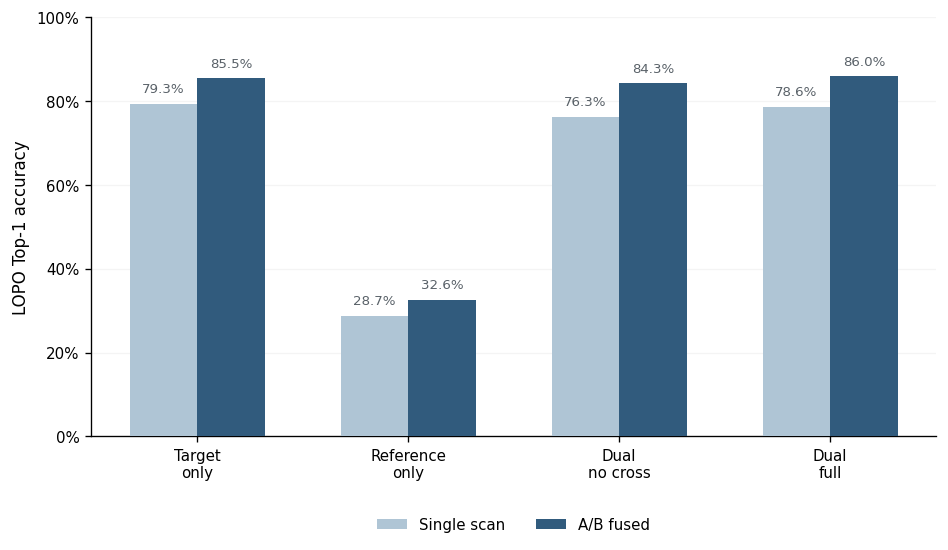

In [7]:
# Figure 1 — channel Top-1, with the selected A/B-fused policy shown explicitly.

variant_order = [
    "Target-only",
    "Reference-only",
    "Dual-no-cross",
    "Dual-full",
]

variant_labels = [
    "Target\nonly",
    "Reference\nonly",
    "Dual\nno cross",
    "Dual\nfull",
]

single_overall = (
    summary[
        (
            summary[
                "evaluation"
            ]
            == "Single-scan"
        )
        &
        (
            summary[
                "scope"
            ]
            == "Overall"
        )
    ]
    .set_index(
        "variant"
    )
    .reindex(
        variant_order
    )
)

fused_overall = (
    summary[
        (
            summary[
                "evaluation"
            ]
            == "A/B fused"
        )
        &
        (
            summary[
                "scope"
            ]
            == "Overall"
        )
    ]
    .set_index(
        "variant"
    )
    .reindex(
        variant_order
    )
)

fig, ax = plt.subplots(
    figsize=(
        8.0,
        4.6,
    )
)

x = np.arange(
    len(
        variant_order
    )
)

width = 0.32

bars1 = ax.bar(
    x
    - width
    / 2,
    100
    * single_overall[
        "top1"
    ].to_numpy(),
    width=width,
    color=LIGHT_BLUE,
    edgecolor="none",
    label="Single scan",
    zorder=3,
)

bars2 = ax.bar(
    x
    + width
    / 2,
    100
    * fused_overall[
        "top1"
    ].to_numpy(),
    width=width,
    color=DARK_BLUE,
    edgecolor="none",
    label="A/B fused",
    zorder=3,
)

for bars in [
    bars1,
    bars2,
]:
    for bar in bars:
        value = (
            bar.get_height()
        )

        ax.annotate(
            f"{value:.1f}%",
            xy=(
                bar.get_x()
                + bar.get_width()
                / 2,
                value,
            ),
            xytext=(
                0,
                5,
            ),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
            color=DARK_GREY,
        )


ax.set_xticks(
    x
)

ax.set_xticklabels(
    variant_labels
)

ax.set_ylabel(
    "LOPO Top-1 accuracy"
)

ax.set_ylim(
    0,
    100,
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, pos: (
            f"{y:.0f}%"
        )
    )
)

ax.grid(
    axis="y",
    alpha=0.13,
    zorder=0,
)

ax.legend(
    frameon=False,
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.16,
    ),
)

fig.subplots_adjust(
    bottom=0.24
)

fig.tight_layout()

save_figure(
    fig,
    "RQ16_Fig1_channel_top1",
)

plt.show()

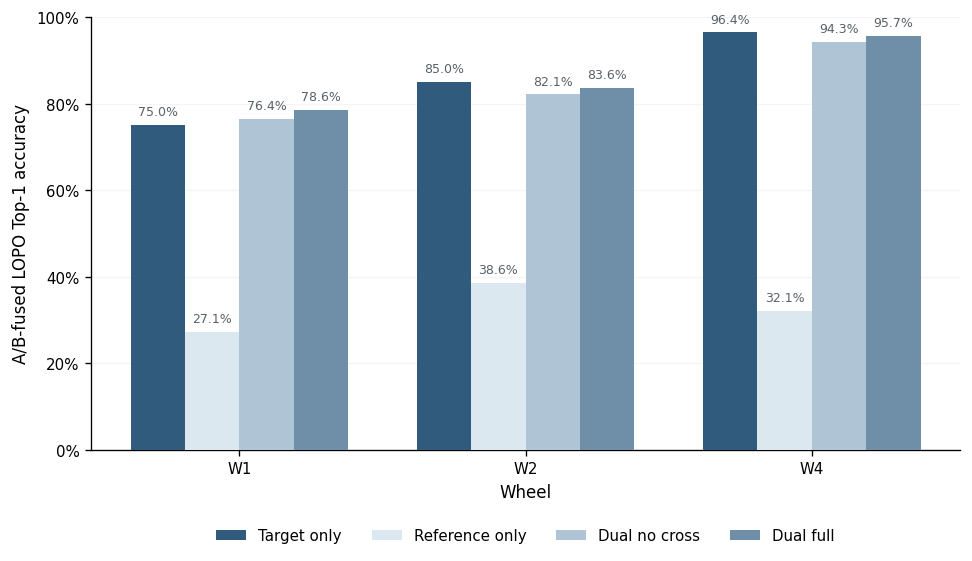

In [8]:
# Figure 2 — fused channel comparison per wheel.

variant_order = [
    "Target-only",
    "Reference-only",
    "Dual-no-cross",
    "Dual-full",
]

wheel_fused = (
    summary[
        (
            summary[
                "evaluation"
            ]
            == "A/B fused"
        )
        &
        (
            summary[
                "scope"
            ].isin([
                "W1",
                "W2",
                "W4",
            ])
        )
    ]
    .pivot(
        index="scope",
        columns="variant",
        values="top1",
    )
    .reindex(
        index=[
            "W1",
            "W2",
            "W4",
        ],
        columns=variant_order,
    )
)

colors = {
    "Target-only": DARK_BLUE,
    "Reference-only": PALE_BLUE,
    "Dual-no-cross": LIGHT_BLUE,
    "Dual-full": MID_BLUE,
}

fig, ax = plt.subplots(
    figsize=(
        8.2,
        4.7,
    )
)

x = np.arange(
    3
)

width = 0.19

offsets = (
    np.arange(
        4
    )
    - 1.5
) * width

for (
    offset,
    variant,
) in zip(
    offsets,
    variant_order,
):
    values = (
        100
        * wheel_fused[
            variant
        ].to_numpy()
    )

    bars = ax.bar(
        x
        + offset,
        values,
        width=width,
        color=colors[
            variant
        ],
        edgecolor="none",
        label=(
            variant.replace(
                "-",
                " ",
            )
        ),
        zorder=3,
    )

    for (
        bar,
        value,
    ) in zip(
        bars,
        values,
    ):
        ax.annotate(
            f"{value:.1f}%",
            xy=(
                bar.get_x()
                + bar.get_width()
                / 2,
                bar.get_height(),
            ),
            xytext=(
                0,
                4,
            ),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=7.5,
            color=DARK_GREY,
        )


ax.set_xticks(
    x
)

ax.set_xticklabels([
    "W1",
    "W2",
    "W4",
])

ax.set_xlabel(
    "Wheel"
)

ax.set_ylabel(
    "A/B-fused LOPO Top-1 accuracy"
)

ax.set_ylim(
    0,
    100,
)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(
        lambda y, pos: (
            f"{y:.0f}%"
        )
    )
)

ax.grid(
    axis="y",
    alpha=0.13,
    zorder=0,
)

ax.legend(
    frameon=False,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(
        0.5,
        -0.15,
    ),
)

fig.subplots_adjust(
    bottom=0.24
)

fig.tight_layout()

save_figure(
    fig,
    "RQ16_Fig2_wheel_channel_ablation",
)

plt.show()

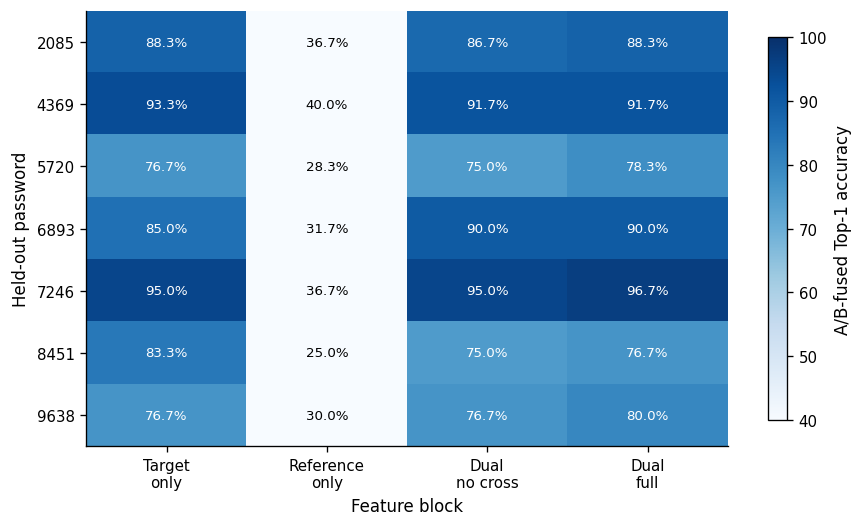

In [9]:
# Figure 3 — held-out-password fused performance.

password_matrix = (
    password_summary[
        password_summary[
            "evaluation"
        ]
        == "A/B fused"
    ]
    .pivot(
        index="password",
        columns="variant",
        values="top1",
    )
    .reindex(
        columns=[
            "Target-only",
            "Reference-only",
            "Dual-no-cross",
            "Dual-full",
        ]
    )
)

fig, ax = plt.subplots(
    figsize=(
        7.6,
        4.5,
    )
)

image = ax.imshow(
    100
    * password_matrix.to_numpy(),
    aspect="auto",
    cmap="Blues",
    vmin=40,
    vmax=100,
)

ax.set_xticks(
    np.arange(
        4
    )
)

ax.set_xticklabels([
    "Target\nonly",
    "Reference\nonly",
    "Dual\nno cross",
    "Dual\nfull",
])

ax.set_yticks(
    np.arange(
        len(
            password_matrix
        )
    )
)

ax.set_yticklabels(
    password_matrix.index.astype(
        str
    )
)

ax.set_xlabel(
    "Feature block"
)

ax.set_ylabel(
    "Held-out password"
)

for i in range(
    password_matrix.shape[
        0
    ]
):
    for j in range(
        password_matrix.shape[
            1
        ]
    ):
        value = (
            100
            * password_matrix.iloc[
                i,
                j,
            ]
        )

        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=8,
            color=(
                "white"
                if value
                >= 72
                else "black"
            ),
        )


cbar = fig.colorbar(
    image,
    ax=ax,
    shrink=0.88,
)

cbar.set_label(
    "A/B-fused Top-1 accuracy"
)

fig.tight_layout()

save_figure(
    fig,
    "RQ16_Fig3_password_channel_heatmap",
)

plt.show()

## 7. Tables and result record

In [10]:
feature_blocks.to_csv(
    RESULT_DIR
    / "RQ16_feature_blocks.csv",
    index=False,
)

candidate_scores.to_csv(
    RESULT_DIR
    / "RQ16_candidate_scores.csv",
    index=False,
)

single_decisions.to_csv(
    RESULT_DIR
    / "RQ16_single_scan_decisions.csv",
    index=False,
)

fused_candidates_all.to_csv(
    RESULT_DIR
    / "RQ16_fused_candidate_scores.csv",
    index=False,
)

fused_decisions.to_csv(
    RESULT_DIR
    / "RQ16_fused_decisions.csv",
    index=False,
)

summary.to_csv(
    RESULT_DIR
    / "RQ16_summary_metrics.csv",
    index=False,
)

password_summary.to_csv(
    RESULT_DIR
    / "RQ16_password_summary.csv",
    index=False,
)


wheel_summary = (
    summary[
        summary[
            "scope"
        ].isin([
            "W1",
            "W2",
            "W4",
        ])
    ]
    .copy()
)

wheel_summary.to_csv(
    RESULT_DIR
    / "RQ16_wheel_summary.csv",
    index=False,
)

tests.to_csv(
    RESULT_DIR
    / "RQ16_password_level_tests.csv",
    index=False,
)

tests.to_csv(
    RESULT_DIR
    / "RQ16_password_level_tests.csv",
    index=False,
)


table1 = summary[
    summary[
        "scope"
    ]
    == "Overall"
].copy()

for (
    src,
    dst,
) in [
    (
        "top1",
        "Top-1",
    ),
    (
        "top2",
        "Top-2",
    ),
    (
        "top3",
        "Top-3",
    ),
]:
    table1[
        dst
    ] = (
        100
        * table1[
            src
        ]
    ).map(
        lambda x: f"{x:.1f}%"
    )


table1[
    "Mean rank"
] = table1[
    "mean_true_rank"
].map(
    lambda x: f"{x:.2f}"
)

table1 = table1[
    [
        "evaluation",
        "variant",
        "n_decisions",
        "Top-1",
        "Top-2",
        "Top-3",
        "Mean rank",
    ]
].rename(
    columns={
        "evaluation": "Evaluation",
        "variant": "Feature block",
        "n_decisions": "N decisions",
    }
)

table1.to_csv(
    RESULT_DIR
    / "RQ16_Table1_channel_summary.csv",
    index=False,
)

with open(
    RESULT_DIR
    / "RQ16_Table1_channel_summary.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        table1.to_latex(
            index=False,
            escape=True,
        )
    )

tests.to_csv(
    RESULT_DIR
    / "RQ16_Table2_password_tests.csv",
    index=False,
)

with open(
    RESULT_DIR
    / "RQ16_Table2_password_tests.tex",
    "w",
    encoding="utf-8",
) as f:
    f.write(
        tests.to_latex(
            index=False,
            escape=True,
        )
    )

display(
    table1
)

display(
    tests
)

,Evaluation,Feature block,N decisions,Top-1,Top-2,Top-3,Mean rank
0,Single-scan,Target-only,840,79.3%,91.2%,95.6%,1.39
4,Single-scan,Reference-only,840,28.7%,44.6%,57.1%,3.70
8,Single-scan,Dual-no-cross,840,76.3%,90.2%,94.9%,1.44
12,Single-scan,Dual-full,840,78.6%,90.4%,95.5%,1.40
16,A/B fused,Target-only,420,85.5%,94.5%,98.3%,1.24
20,A/B fused,Reference-only,420,32.6%,49.8%,61.9%,3.43
24,A/B fused,Dual-no-cross,420,84.3%,94.8%,97.9%,1.25
28,A/B fused,Dual-full,420,86.0%,95.5%,97.9%,1.23


,comparison,n_passwords,mean_delta_pp,median_delta_pp,A_better_passwords,equal_passwords,B_better_passwords,p_two_sided
0,Reference-only vs Target-only,7,-52.857143,-53.333333,0,0,7,0.015625
1,Dual-no-cross vs Target-only,7,-1.190476,-1.666667,1,2,4,0.437500
2,Dual-full vs Target-only,7,0.476190,1.666667,4,1,2,0.750000
3,Dual-full vs Dual-no-cross,7,1.666667,1.666667,5,2,0,0.062500


In [11]:
fused_overall = (
    summary[
        (
            summary[
                "evaluation"
            ]
            == "A/B fused"
        )
        &
        (
            summary[
                "scope"
            ]
            == "Overall"
        )
    ]
    .set_index(
        "variant"
    )
)

single_overall = (
    summary[
        (
            summary[
                "evaluation"
            ]
            == "Single-scan"
        )
        &
        (
            summary[
                "scope"
            ]
            == "Overall"
        )
    ]
    .set_index(
        "variant"
    )
)


conclusion = {
    "research_question": (
        "Which acoustic channel representation gives the strongest password-generalising "
        "Current-only Digit Scan decisions: target/contact, motor-reference, both channels, "
        "or both channels with explicit cross-channel features?"
    ),
    "analysis_type": (
        "Controlled channel ablation under fixed RQ14/RQ15 direction and repeat treatment"
    ),
    "primary_AB_fused_top1": {
        variant: float(
            fused_overall.loc[
                variant,
                "top1",
            ]
        )
        for variant
        in FEATURE_BLOCKS
    },
    "single_scan_top1": {
        variant: float(
            single_overall.loc[
                variant,
                "top1",
            ]
        )
        for variant
        in FEATURE_BLOCKS
    },
    "password_level_tests": (
        tests.to_dict(
            orient="records"
        )
    ),
    "relation_to_RQ3": (
        "RQ3 established that both recording paths contain true-gate information and "
        "could not support a contact-only source attribution. RQ16 asks the different "
        "engineering question: which channel representation gives the strongest "
        "shortcut-resistant cross-password ranking."
    ),
    "selected_working_representation": "Dual-full",
    "selection_status": (
        "Working representation retained for subsequent capacity/shared-model tests; "
        "not statistically superior to Target-only in this fixed linear ablation."
    ),
    "interpretation": (
        "The motor-reference channel contains reproducible information but is much weaker than "
        "the contact/target channel under password-grouped evaluation. Target-only is already a "
        "strong representation, while naive concatenation of the two channel blocks does not improve "
        "it. The full dual/cross representation is only marginally higher on the A/B-fused primary "
        "metric, and the password-level test does not establish superiority over Target-only. "
        "Explicit cross-channel terms nevertheless recover a small, consistent part of the performance "
        "lost by naive dual concatenation."
    ),
    "limitation": (
        "All feature blocks use the same fixed C=0.10 despite different dimensionality. "
        "The reference channel also shows light clipping in some later batches. Predictive "
        "reference-channel information does not prove that the signal originates in the motor, "
        "because lock-state information can propagate through mechanical coupling."
    ),
    "decision": (
        "Retain Dual-full as the working representation for the next capacity/shared-model "
        "ablations because it is the nominal best A/B-fused result and explicit cross-channel "
        "terms improve on naive dual concatenation. Do not claim that Dual-full is statistically "
        "superior to Target-only; Target-only remains a strong, simpler near-equivalent baseline. "
        "Reject Reference-only as the primary representation."
    ),
    "next_step": (
        "The next controlled ablation tests model capacity under the selected direction, "
        "repeat and channel configuration."
    ),
}

with open(
    RESULT_DIR
    / "RQ16_conclusion.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        conclusion,
        f,
        indent=2,
    )


run_info = {
    "notebook": (
        "16_RQ16_Channel_Ablation.ipynb"
    ),
    "feature_layout": {
        "Ch1_target": [
            0,
            250,
        ],
        "Ch2_reference": [
            250,
            500,
        ],
        "Ch1_minus_Ch2_logmel": [
            500,
            692,
        ],
        "cross_scalars": [
            692,
            695,
        ],
    },
    "direction_treatment": (
        "Separate wheel × direction from RQ14"
    ),
    "repeat_treatment": (
        "A+B training; primary A/B fusion from RQ15"
    ),
    "C": LOGREG_C,
    "primary_metric": (
        "Password-grouped A/B-fused LOPO Top-1"
    ),
}

with open(
    RESULT_DIR
    / "RQ16_run_info.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        run_info,
        f,
        indent=2,
    )


print(
    json.dumps(
        conclusion,
        indent=2,
    )
)

print(
    "\nSaved outputs:"
)

for path in sorted(
    RESULT_DIR.glob(
        "RQ16_*"
    )
):
    print(
        " -",
        path.name,
    )

{
  "research_question": "Which acoustic channel representation gives the strongest password-generalising Current-only Digit Scan decisions: target/contact, motor-reference, both channels, or both channels with explicit cross-channel features?",
  "analysis_type": "Controlled channel ablation under fixed RQ14/RQ15 direction and repeat treatment",
  "primary_AB_fused_top1": {
    "Target-only": 0.8547619047619047,
    "Reference-only": 0.3261904761904762,
    "Dual-no-cross": 0.8428571428571429,
    "Dual-full": 0.8595238095238096
  },
  "single_scan_top1": {
    "Target-only": 0.7928571428571428,
    "Reference-only": 0.2869047619047619,
    "Dual-no-cross": 0.763095238095238,
    "Dual-full": 0.7857142857142857
  },
  "password_level_tests": [
    {
      "comparison": "Reference-only vs Target-only",
      "n_passwords": 7,
      "mean_delta_pp": -52.85714285714286,
      "median_delta_pp": -53.333333333333336,
      "A_better_passwords": 0,
      "equal_passwords": 0,
      "B_bette